<a href="https://colab.research.google.com/github/akashgardas/Deep-Learning/blob/perceptron/models/perceptron/Perceptron_email_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🏢 Business Scenario: Email Spam Detection for a Startup

A startup company is building a **basic email filtering system** to classify emails as:

- `1 → Spam`
- `0 → Not Spam`

The company wants to first implement a **simple Perceptron model** before moving to complex neural networks.

They identified two key binary features from emails:

1.  **Contains Suspicious Keywords** (e.g., “lottery”, “prize”, “urgent”)
    - Yes → 1
    - No → 0
2.  **Sender is Unknown**
    - Yes → 1
    - No → 0

So each email is represented as:

$$
X = (x_1, x_2)
$$

Where,

- $x_1$ = Suspicious keywords
- $x_2$ = Unknown sender
---
### Part 1 – Conceptual Understanding

1.  Is this dataset **linearly separable**?
2.  Can a single-layer Perceptron solve this problem?
3.  What logical function does this resemble?
---
### Part 2 - Mathematical Formulation

Assume:  
- Initial weights:  
W1=0,w2=0  
- Bias: b= 0  
- Learning rate: n = 1

Use the Perceptron learning rule

Perform one full epoch manually
1\. Compute weighted sum

2\. Apply step activation:  
- Ifz ≥ 0- 1  
- Else - 0  
3\. Update weights and bias after each example.
---
### Part 3 – Decision Boundary

After training:

1.  Write the final equation of the decision boundary.
2.  Plot the decision boundary.
3.  Explain geometrically how Perceptron separates spam and non-spam emails.

* * *

### Part 4 – Critical Thinking

1.  What happens if we change E3 output to 0?
2.  Will Perceptron still converge?
3.  If not, why?
4.  What limitation of Perceptron does this expose?

# Perceptron

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Preparation

In [ ]:
# Dataset from the business scenario
data = {
    "Email": ["E1", "E2", "E3", "E4"],
    "x1": [1, 1, 0, 0], # Suspicious Keywords
    "x2": [1, 0, 1, 0], # Unknown Sender
    "y": [1, 1, 1, 0]   # Output (Spam?)
}

df = pd.DataFrame(data)
X = df[['x1', 'x2']].values
y = df['y'].values

## Perceptron Model Implementation

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.1):
        self.w = np.array([0.0, 0.0]) # w1, w2
        self.b = 0.0                  # bias
        self.eta = learning_rate       # learning rate

    def predict(self, x):
        # Step 1 & 2: Compute weighted sum and apply step activation
        z = np.dot(x, self.w) + self.b
        return 1 if z >= 0 else 0

    def train(self, X, y, epochs=10):
        for epoch in range(epochs):
            print(f"--- Epoch {epoch + 1} ---")
            for i in range(len(X)):
                prediction = self.predict(X[i])
                # Step 3: Update weights and bias using the learning rule
                # w = w + eta * (target - prediction) * x
                error = y[i] - prediction
                self.w += self.eta * error * X[i]
                self.b += self.eta * error
                print(f"Email {i+1}: Prediction={prediction}, Target={y[i]}, Updated Weights={self.w}, Bias={self.b}")

# Initialize and run one full epoch manually [cite: 33]
model = Perceptron(learning_rate=0.1)
model.train(X, y, epochs=5)

--- Epoch 1 ---
Email 1: Prediction=1, Target=1, Updated Weights=[0. 0.], Bias=0.0
Email 2: Prediction=1, Target=1, Updated Weights=[0. 0.], Bias=0.0
Email 3: Prediction=1, Target=1, Updated Weights=[0. 0.], Bias=0.0
Email 4: Prediction=1, Target=0, Updated Weights=[0. 0.], Bias=-0.1
--- Epoch 2 ---
Email 1: Prediction=0, Target=1, Updated Weights=[0.1 0.1], Bias=0.0
Email 2: Prediction=1, Target=1, Updated Weights=[0.1 0.1], Bias=0.0
Email 3: Prediction=1, Target=1, Updated Weights=[0.1 0.1], Bias=0.0
Email 4: Prediction=1, Target=0, Updated Weights=[0.1 0.1], Bias=-0.1
--- Epoch 3 ---
Email 1: Prediction=1, Target=1, Updated Weights=[0.1 0.1], Bias=-0.1
Email 2: Prediction=1, Target=1, Updated Weights=[0.1 0.1], Bias=-0.1
Email 3: Prediction=1, Target=1, Updated Weights=[0.1 0.1], Bias=-0.1
Email 4: Prediction=0, Target=0, Updated Weights=[0.1 0.1], Bias=-0.1
--- Epoch 4 ---
Email 1: Prediction=1, Target=1, Updated Weights=[0.1 0.1], Bias=-0.1
Email 2: Prediction=1, Target=1, Updated

## Visualizing decision boundary

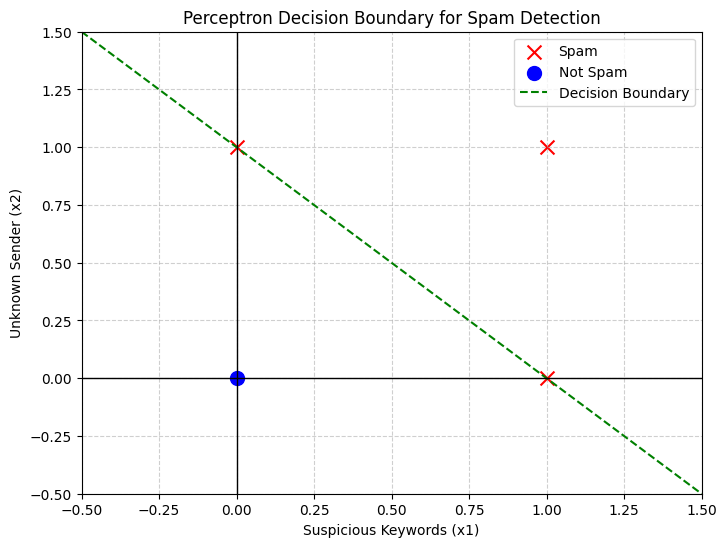

In [ ]:
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(8, 6))

    # Plot data points
    for i in range(len(y)):
        marker = 'x' if y[i] == 1 else 'o'
        color = 'red' if y[i] == 1 else 'blue'
        plt.scatter(X[i, 0], X[i, 1], c=color, marker=marker, s=100, label='Spam' if y[i] == 1 and i == 0 else 'Not Spam' if y[i] == 0 else "")

    # Calculate boundary: w1*x1 + w2*x2 + b = 0 => x2 = -(w1/w2)x1 - b/w2 [cite: 42]
    x1_values = np.linspace(-0.5, 1.5, 10)
    if model.w[1] != 0:
        x2_values = -(model.w[0] / model.w[1]) * x1_values - (model.b / model.w[1])
        plt.plot(x1_values, x2_values, '--g', label="Decision Boundary")

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('Suspicious Keywords (x1)')
    plt.ylabel('Unknown Sender (x2)')
    plt.title('Perceptron Decision Boundary for Spam Detection')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_decision_boundary(X, y, model)